<a href="https://colab.research.google.com/github/yxngwei/evolutionary-game-simulation/blob/main/simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
"""
game.py

Defines the payoff rules for the Prisoner's Dilemma.

Two players each choose to COOPERATE or DEFECT.
The payoff table below is the classic textbook version:

                Other: Cooperate    Other: Defect
You: Cooperate        3, 3               0, 5
You: Defect           5, 0               1, 1

Rule of thumb for why this is a "dilemma":
- No matter what the other player does, YOU personally score higher by
  defecting (5>3 if they cooperate, 1>0 if they defect).
- But if BOTH players think that way, both defect and both get only 1,
  instead of both getting 3 by cooperating. Individually rational,
  collectively worse off.
"""

COOPERATE = "C"
DEFECT = "D"

# payoff[my_move][their_move] = my_score
PAYOFF = {
    COOPERATE: {COOPERATE: 3, DEFECT: 0},
    DEFECT: {COOPERATE: 5, DEFECT: 1},
}


def play_round(move_a, move_b):
    """Return (score_a, score_b) for one round given both players' moves."""
    score_a = PAYOFF[move_a][move_b]
    score_b = PAYOFF[move_b][move_a]
    return score_a, score_b


def play_match(strategy_a, strategy_b, rounds=10):
    """
    Play an ITERATED match: the same two strategies play multiple rounds
    in a row, each remembering the full history so far (needed for
    strategies like Tit-for-Tat that react to the opponent's last move).

    strategy_a / strategy_b: functions with signature
        move = strategy(my_history, their_history)
    where my_history/their_history are lists of past moves (empty on round 1).

    Returns (total_score_a, total_score_b) summed across all rounds.
    """
    history_a, history_b = [], []
    total_a, total_b = 0, 0

    for _ in range(rounds):
        move_a = strategy_a(history_a, history_b)
        move_b = strategy_b(history_b, history_a)

        score_a, score_b = play_round(move_a, move_b)
        total_a += score_a
        total_b += score_b

        history_a.append(move_a)
        history_b.append(move_b)

    return total_a, total_b

In [4]:
"""
population.py

Defines a few simple strategies, and the replicator dynamics rule that
decides how the population's mix of strategies shifts each generation.
"""

import numpy as np
# from game import COOPERATE, DEFECT, play_match


# --- STRATEGIES -------------------------------------------------------
# Each strategy is a function: strategy(my_history, their_history) -> move
# my_history/their_history are lists of past moves in THIS match so far.

def always_cooperate(my_history, their_history):
    return COOPERATE


def always_defect(my_history, their_history):
    return DEFECT


def tit_for_tat(my_history, their_history):
    """Cooperate first, then copy whatever the opponent did last round."""
    if not their_history:
        return COOPERATE
    return their_history[-1]


STRATEGIES = {
    "Always Cooperate": always_cooperate,
    "Always Defect": always_defect,
    "Tit-for-Tat": tit_for_tat,
}

STRATEGY_NAMES = list(STRATEGIES.keys())


# --- REPLICATOR DYNAMICS ------------------------------------------------

def average_payoffs(population_shares, rounds_per_match=10):
    """
    Given the current share of the population using each strategy
    (a dict: name -> fraction, fractions sum to 1), compute the AVERAGE
    score each strategy earns when playing against the whole population
    (weighted by how common each opponent strategy currently is).

    This is the key "who's doing well right now" calculation.
    """
    avg_scores = {}

    for name_a, strategy_a in STRATEGIES.items():
        expected_score = 0.0

        for name_b, strategy_b in STRATEGIES.items():
            share_b = population_shares[name_b]
            if share_b == 0:
                continue

            total_a, _ = play_match(strategy_a, strategy_b, rounds=rounds_per_match)
            avg_score_this_matchup = total_a / rounds_per_match

            # Weight by how likely this opponent is to be encountered
            expected_score += share_b * avg_score_this_matchup

        avg_scores[name_a] = expected_score

    return avg_scores


def replicator_step(population_shares, rounds_per_match=10):
    """
    One generation of replicator dynamics:
    strategies that scored ABOVE the population average grow their share,
    strategies BELOW average shrink. This is the standard replicator
    equation from evolutionary game theory.
    """
    scores = average_payoffs(population_shares, rounds_per_match)
    mean_score = sum(population_shares[name] * scores[name] for name in STRATEGY_NAMES)

    new_shares = {}
    for name in STRATEGY_NAMES:
        # Standard replicator equation: growth proportional to relative fitness
        new_shares[name] = population_shares[name] * (scores[name] / mean_score)

    # Normalize so shares still sum to exactly 1 (guards against float drift)
    total = sum(new_shares.values())
    return {name: value / total for name, value in new_shares.items()}


def run_simulation(generations=100, rounds_per_match=10, seed=None):
    """
    Run the full simulation starting from an equal 3-way split and
    return a history: a list of dicts (one per generation) showing the
    population share of each strategy at that point in time.
    """
    if seed is not None:
        np.random.seed(seed)

    shares = {name: 1 / len(STRATEGY_NAMES) for name in STRATEGY_NAMES}
    history = [shares.copy()]

    for _ in range(generations):
        shares = replicator_step(shares, rounds_per_match)
        history.append(shares.copy())

    return history


Final population mix after 100 generations:
  Always Cooperate    :  13.9%
  Always Defect       :   0.0%
  Tit-for-Tat         :  86.1%


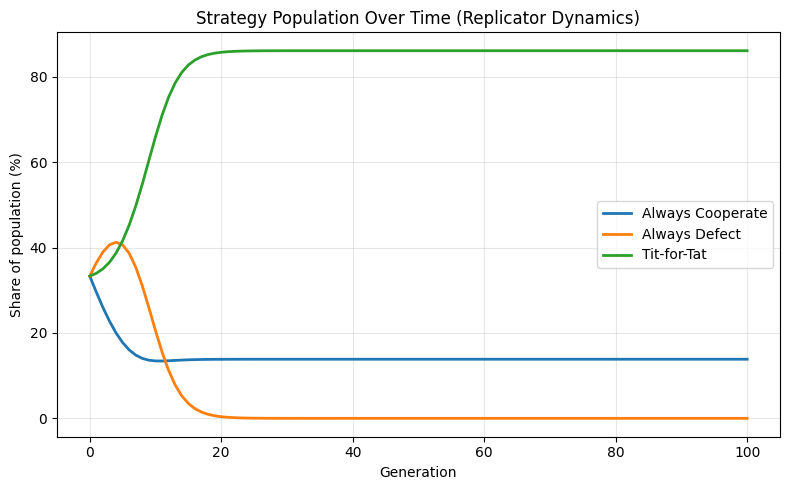


Plot saved to ../results/strategy_convergence.png


In [5]:
"""
simulate.py

Run this file to:
1. Simulate the population evolving over many generations
2. Print the final equilibrium mix
3. Save a plot showing how the strategy mix changed over time

Usage:
    python simulate.py
"""

import matplotlib.pyplot as plt
# from population import run_simulation, STRATEGY_NAMES

GENERATIONS = 100
ROUNDS_PER_MATCH = 10


def main():
    history = run_simulation(generations=GENERATIONS, rounds_per_match=ROUNDS_PER_MATCH)

    # --- Print the final result ---
    final = history[-1]
    print("\nFinal population mix after {} generations:".format(GENERATIONS))
    for name in STRATEGY_NAMES:
        print(f"  {name:20s}: {final[name] * 100:5.1f}%")

    # --- Build the plot ---
    generations_axis = list(range(len(history)))

    plt.figure(figsize=(8, 5))
    for name in STRATEGY_NAMES:
        series = [gen[name] * 100 for gen in history]
        plt.plot(generations_axis, series, label=name, linewidth=2)

    plt.xlabel("Generation")
    plt.ylabel("Share of population (%)")
    plt.title("Strategy Population Over Time (Replicator Dynamics)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = "../results/strategy_convergence.png"
    import os
    os.makedirs("../results", exist_ok=True)
    plt.show()
    # plt.savefig(output_path, dpi=150)
    print(f"\nPlot saved to {output_path}")


if __name__ == "__main__":
    main()


Simulated equilibrium cooperation rate: 100.0%
Real-world early-round benchmark:        ~50% (Zelmer, 2003)
Real-world late-round benchmark:         ~15% (Zelmer, 2003)


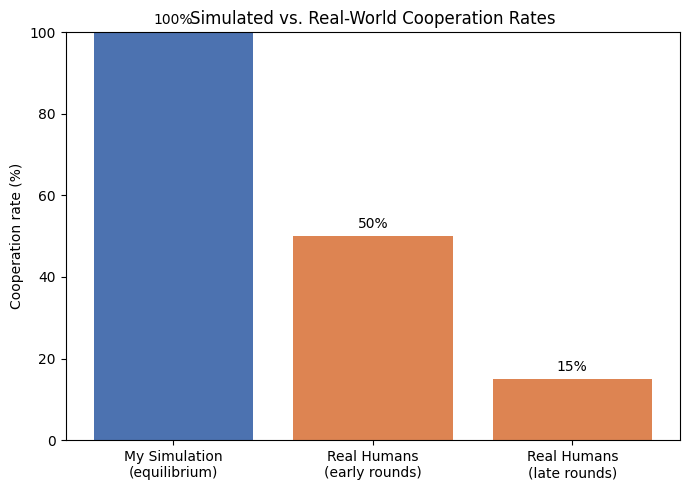


Comparison chart saved to ../results/cooperation_comparison.png


In [8]:
"""
compare.py

Computes the ACTUAL cooperation rate from the final simulated population
(not just strategy share), then compares it against a real-world benchmark
from public goods game experiments.
"""

import matplotlib.pyplot as plt
# from game import COOPERATE, play_match
# from population import run_simulation, STRATEGIES, STRATEGY_NAMES

GENERATIONS = 100
ROUNDS_PER_MATCH = 10

# Real-world benchmark (Zelmer, 2003 meta-analysis of public goods experiments)
REAL_WORLD_EARLY_ROUND_RATE = 50   # midpoint of the commonly cited 40-60% range
REAL_WORLD_LATE_ROUND_RATE = 15    # midpoint of the commonly cited 10-20% range


def cooperation_rate(population_shares, rounds_per_match=ROUNDS_PER_MATCH, samples=2000):
    """
    Estimate the actual % of individual MOVES that are Cooperate, given a
    population mix. Randomly pairs up strategies (weighted by their share)
    and counts how many of the resulting moves were 'C'.
    """
    import random
    names = STRATEGY_NAMES
    weights = [population_shares[n] for n in names]

    total_moves = 0
    cooperate_moves = 0

    for _ in range(samples):
        name_a, name_b = random.choices(names, weights=weights, k=2)
        strat_a, strat_b = STRATEGIES[name_a], STRATEGIES[name_b]

        history_a, history_b = [], []
        for _ in range(rounds_per_match):
            move_a = strat_a(history_a, history_b)
            move_b = strat_b(history_b, history_a)
            history_a.append(move_a)
            history_b.append(move_b)

            total_moves += 2
            cooperate_moves += (move_a == COOPERATE) + (move_b == COOPERATE)

    return 100 * cooperate_moves / total_moves


def main():
    history = run_simulation(generations=GENERATIONS, rounds_per_match=ROUNDS_PER_MATCH)
    final_shares = history[-1]

    sim_rate = cooperation_rate(final_shares)

    print(f"\nSimulated equilibrium cooperation rate: {sim_rate:.1f}%")
    print(f"Real-world early-round benchmark:        ~{REAL_WORLD_EARLY_ROUND_RATE}% (Zelmer, 2003)")
    print(f"Real-world late-round benchmark:         ~{REAL_WORLD_LATE_ROUND_RATE}% (Zelmer, 2003)")

    # --- comparison bar chart ---
    labels = ["My Simulation\n(equilibrium)", "Real Humans\n(early rounds)", "Real Humans\n(late rounds)"]
    values = [sim_rate, REAL_WORLD_EARLY_ROUND_RATE, REAL_WORLD_LATE_ROUND_RATE]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=["#4C72B0", "#DD8452", "#DD8452"])
    plt.ylabel("Cooperation rate (%)")
    plt.title("Simulated vs. Real-World Cooperation Rates")
    plt.ylim(0, 100)
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, value + 2, f"{value:.0f}%", ha="center")
    plt.tight_layout()
    # plt.savefig("../results/cooperation_comparison.png", dpi=150)
    plt.show()
    print("\nComparison chart saved to ../results/cooperation_comparison.png")


if __name__ == "__main__":
    main()